<a href="https://colab.research.google.com/github/WeydisonAndrade/PraticaAnaliseDeDadosPython/blob/main/PraticandoAn%C3%A1lisedeDadosComPython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Configuração visual
plt.rcParams['figure.figsize'] = (8,5)

# Carrega o arquivo CSV que já está no ambiente do Colab
df = pd.read_csv('/content/Planilha CSV (1).csv', encoding='latin1')

# Exibe as primeiras linhas do DataFrame para verificar
print(df.head())

                   Aluno  Prova 1  Prova 2  Prova 3  Prova 4  Nota final
0        Marcelo Barbosa      6.5      8.3      9.2      7.2         NaN
1         Rafaela Santos      8.3      4.5      7.5      4.5         NaN
2         Ronaldo Santos      7.0      2.1      8.9      8.9         NaN
3  Lucas Gabriel Ribeiro      5.9      9.8      6.4      6.1         NaN
4         Luana da Silva      9.2      5.6      3.1      9.8         NaN


Exploração de dados


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Aluno       20 non-null     object 
 1   Prova 1     20 non-null     float64
 2   Prova 2     20 non-null     float64
 3   Prova 3     20 non-null     float64
 4   Prova 4     20 non-null     float64
 5   Nota final  0 non-null      float64
dtypes: float64(5), object(1)
memory usage: 47.0+ KB


In [5]:
df.describe()

,Prova 1,Prova 2,Prova 3,Prova 4,Nota final
count,20.000000,20.000000,20.000000,20.000000,0.0
mean,6.545000,5.005000,6.665000,6.130000,NaN
std,2.651608,2.919891,2.145565,2.827701,NaN
min,0.000000,0.500000,2.800000,0.000000,NaN
25%,5.800000,2.425000,5.100000,4.450000,NaN
50%,6.900000,4.950000,6.650000,6.800000,NaN
75%,8.350000,7.325000,8.225000,8.075000,NaN
max,9.900000,9.800000,9.900000,10.000000,NaN


In [6]:
df.isnull().sum()

,0
Aluno,979
Prova 1,979
Prova 2,979
Prova 3,979
Prova 4,979
Nota final,999


Tratamento e criação da média

In [9]:
# Selecionando colunas da prova
colunas_notas = ['Prova 1', 'Prova 2', 'Prova 3', 'Prova 4']
# Criando média
df['Media'] = df[colunas_notas].mean(axis=1)
df[['Aluno', 'Media']].head()

,Aluno,Media
0,Marcelo Barbosa,7.800
1,Rafaela Santos,6.200
2,Ronaldo Santos,6.725
3,Lucas Gabriel Ribeiro,7.050
4,Luana da Silva,6.925


Gráfico de dispersão

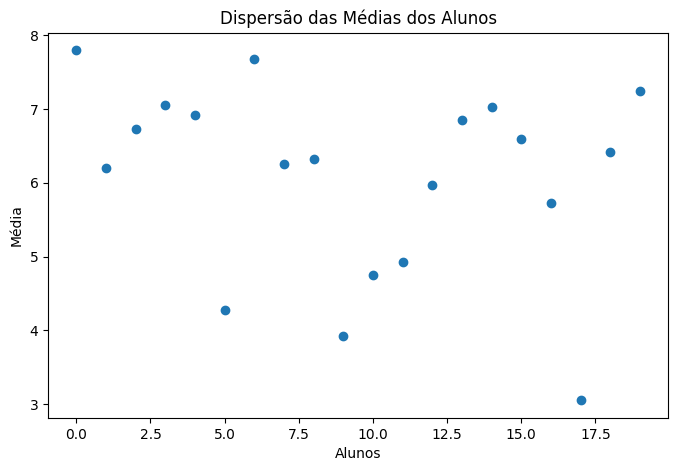

In [10]:
plt.figure()
plt.scatter(range(len(df)), df['Media'])

plt.xlabel('Alunos')
plt.ylabel('Média')
plt.title('Dispersão das Médias dos Alunos')

plt.show()

Gráfico de colunas

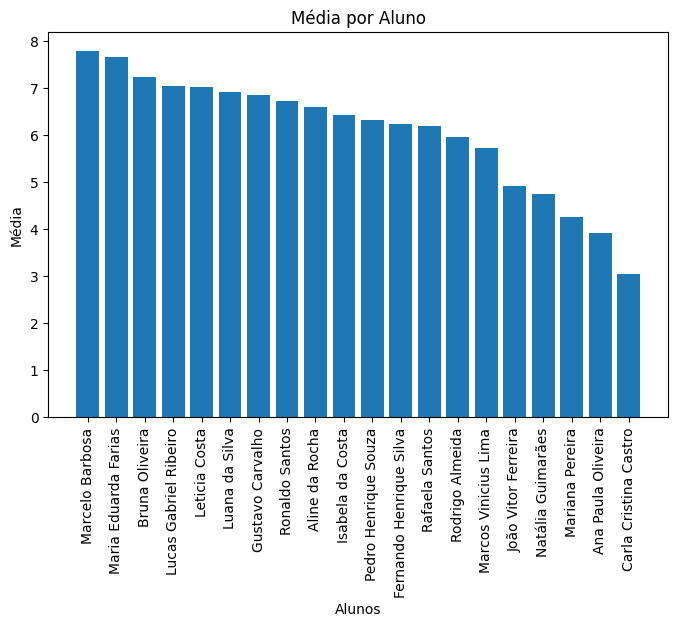

In [12]:
df_sorted = df.sort_values(by='Media', ascending=False)

# Filtrar apenas alunos com nomes válidos para o gráfico de barras
df_sorted_valid_alunos = df_sorted.dropna(subset=['Aluno'])

plt.figure()
plt.bar(df_sorted_valid_alunos['Aluno'], df_sorted_valid_alunos['Media'])

plt.xticks(rotation=90)
plt.xlabel('Alunos')
plt.ylabel('Média')
plt.title('Média por Aluno')

plt.show()

Gráfico de pareto

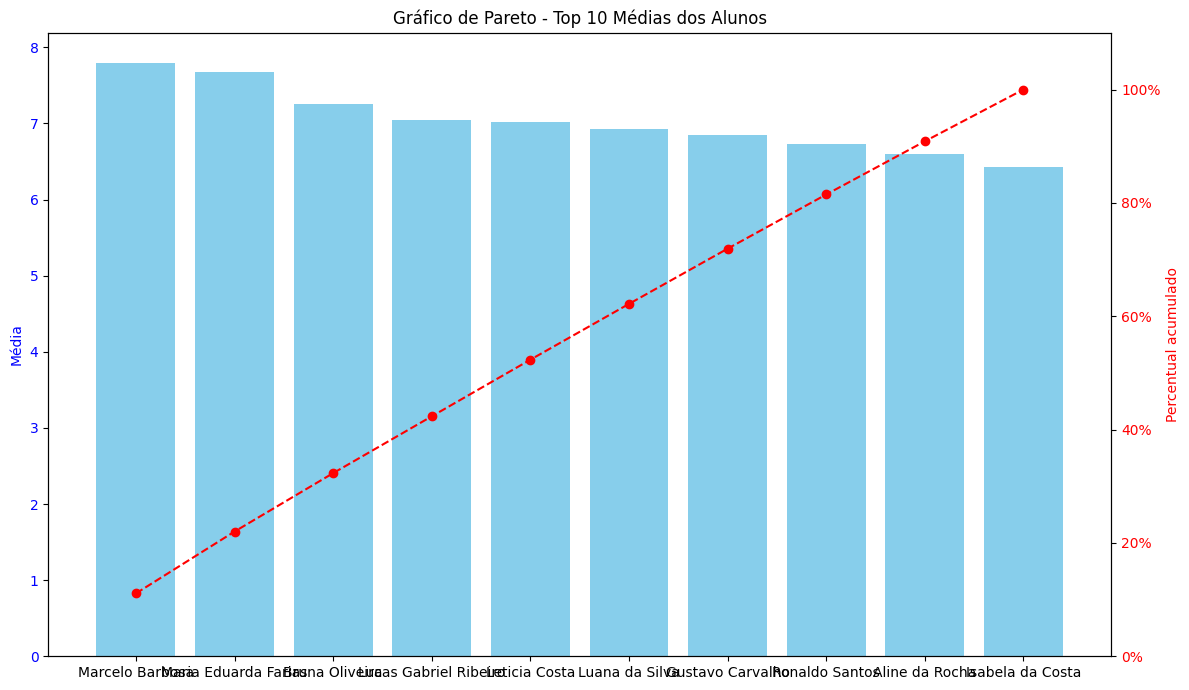

In [18]:
df_pareto = df.sort_values(by='Media', ascending=False)

# Filtrar apenas alunos com nomes válidos para o gráfico de Pareto
df_pareto_valid_alunos = df_pareto.dropna(subset=['Aluno']).copy()

# Selecionar os top 10 alunos para um gráfico mais limpo
df_pareto_top_n = df_pareto_valid_alunos.head(10).copy()

# Percentual acumulado para os top N alunos
df_pareto_top_n['Percentual'] = df_pareto_top_n['Media'].cumsum() / df_pareto_top_n['Media'].sum()

fig, ax1 = plt.subplots(figsize=(12, 7)) # Aumentei um pouco o tamanho da figura para melhor visualização

# Barras (frequência)
ax1.bar(df_pareto_top_n['Aluno'], df_pareto_top_n['Media'], color='skyblue')
ax1.set_ylabel('Média', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Linha (acumulado)
ax2 = ax1.twinx()
ax2.plot(df_pareto_top_n['Aluno'], df_pareto_top_n['Percentual'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Percentual acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1.1) # Ajusta o limite para o percentual
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) # Formata como porcentagem

plt.xticks(rotation=90, ha='right') # Rotação de 90 graus para os rótulos do eixo X
plt.title('Gráfico de Pareto - Top 10 Médias dos Alunos')
fig.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()